# Euromillones V4 - Top combinaciones, exportación y comparación cruda vs final

Esta versión añade:
- top 5 combinaciones sugeridas
- exportación opcional a CSV
- comparación entre predicción cruda de la red y combinación final mezclada
- ranking más cómodo de revisar

**Aviso:** sigue siendo un experimento sobre un proceso esencialmente aleatorio.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)

## 1. Carga de datos

In [2]:
csv_path = 'EuroMillions_numbers.csv'
df = pd.read_csv(csv_path, delimiter=';')
df = df[['N1', 'N2', 'N3', 'N4', 'N5', 'E1', 'E2']].copy()

num_cols = ['N1', 'N2', 'N3', 'N4', 'N5']
star_cols = ['E1', 'E2']

print('Filas:', len(df))
display(df.head())

Filas: 1859


,N1,N2,N3,N4,N5,E1,E2
0,3,27,29,4,37,6,5
1,49,22,19,15,46,9,2
2,24,1,34,4,36,8,6
3,9,25,1,40,23,3,9
4,48,20,45,21,12,6,5


## 2. Funciones auxiliares

In [3]:
def make_sequences_from_scaled(values_scaled, window_length):
    X, y = [], []
    for i in range(len(values_scaled) - window_length):
        X.append(values_scaled[i:i+window_length])
        y.append(values_scaled[i+window_length])
    return np.array(X), np.array(y)

def build_lstm_model(window_length, n_features, units_1=32, units_2=16, dropout=0.2):
    model = Sequential([
        Input(shape=(window_length, n_features)),
        LSTM(units_1, return_sequences=True),
        Dropout(dropout),
        LSTM(units_2),
        Dropout(dropout),
        Dense(n_features)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def recent_frequency_scores(df_source, cols, max_value, recent_window=100):
    recent = df_source[cols].tail(recent_window).values.flatten()
    counts = np.bincount(recent, minlength=max_value + 1).astype(float)
    scores = counts / counts.sum() if counts.sum() > 0 else counts
    return scores

def proximity_scores(raw_pred, max_value, tau=4.0):
    values = np.arange(1, max_value + 1)
    scores = np.zeros(max_value + 1)
    for x in raw_pred:
        scores[1:] += np.exp(-np.abs(values - x) / tau)
    scores[1:] = scores[1:] / scores[1:].sum()
    return scores

def select_top_unique(scores, k):
    idx = np.argsort(scores[1:])[::-1] + 1
    return sorted(idx[:k].tolist())

def rounded_unique_from_raw(raw_values, min_v, max_v, k):
    vals = np.clip(np.round(raw_values), min_v, max_v).astype(int).tolist()
    out = []
    for v in vals:
        if v not in out:
            out.append(v)
    if len(out) < k:
        available = [x for x in range(min_v, max_v + 1) if x not in out]
        need = k - len(out)
        out.extend(available[:need])
    return sorted(out[:k])

def evaluate_hits(y_true_real, y_pred_real, n_num=5, n_star=2):
    num_hits, star_hits = [], []
    for i in range(len(y_true_real)):
        real_nums = set(np.clip(np.round(y_true_real[i][:n_num]), 1, 50).astype(int).tolist())
        pred_nums = set(np.clip(np.round(y_pred_real[i][:n_num]), 1, 50).astype(int).tolist())
        real_stars = set(np.clip(np.round(y_true_real[i][n_num:n_num+n_star]), 1, 12).astype(int).tolist())
        pred_stars = set(np.clip(np.round(y_pred_real[i][n_num:n_num+n_star]), 1, 12).astype(int).tolist())
        num_hits.append(len(real_nums & pred_nums))
        star_hits.append(len(real_stars & pred_stars))
    return np.array(num_hits), np.array(star_hits)

def summary_from_hits(num_hits, star_hits):
    return {
        'media aciertos números': float(np.mean(num_hits)),
        'media aciertos estrellas': float(np.mean(star_hits)),
        '% sorteos con >=1 número': float(np.mean(num_hits >= 1) * 100),
        '% sorteos con >=1 estrella': float(np.mean(star_hits >= 1) * 100),
        '% sorteos con >=2 números': float(np.mean(num_hits >= 2) * 100),
        '% sorteos con 2 estrellas': float(np.mean(star_hits >= 2) * 100),
    }

def make_baseline_prediction_rows(df_source, num_cols, star_cols, recent_window=100):
    num_scores = recent_frequency_scores(df_source, num_cols, 50, recent_window)
    star_scores = recent_frequency_scores(df_source, star_cols, 12, recent_window)
    nums = select_top_unique(num_scores, 5)
    stars = select_top_unique(star_scores, 2)
    return np.array(nums + stars, dtype=float)

def make_weighted_combo(raw_nums, raw_stars, alpha_num, alpha_star, df_source, recent_window=100):
    num_freq_scores = recent_frequency_scores(df_source, num_cols, 50, recent_window)
    star_freq_scores = recent_frequency_scores(df_source, star_cols, 12, recent_window)
    num_prox_scores = proximity_scores(raw_nums, 50, tau=4.0)
    star_prox_scores = proximity_scores(raw_stars, 12, tau=2.0)
    num_blended = alpha_num * num_prox_scores + (1 - alpha_num) * num_freq_scores
    star_blended = alpha_star * star_prox_scores + (1 - alpha_star) * star_freq_scores
    nums = select_top_unique(num_blended, 5)
    stars = select_top_unique(star_blended, 2)
    return nums, stars, num_blended, star_blended


## 3. Configuración

In [4]:
window_candidates = [20, 35, 50, 75, 100]
alpha_num_candidates = [0.30, 0.50, 0.65, 0.80]
alpha_star_candidates = [0.30, 0.50, 0.60, 0.80]

epochs = 60
batch_size = 32
patience = 8
recent_window = 100
test_ratio = 0.20

print('Búsqueda total:', len(window_candidates) * len(alpha_num_candidates) * len(alpha_star_candidates), 'configuraciones')

Búsqueda total: 80 configuraciones


## 4. Búsqueda de configuraciones

In [5]:
results = []

for window_length in window_candidates:
    print(f'===== Ventana {window_length} =====')
    
    num_data = df[num_cols].copy()
    star_data = df[star_cols].copy()
    
    split_raw_num = int(len(num_data) * (1 - test_ratio))
    split_raw_star = int(len(star_data) * (1 - test_ratio))
    train_num_df = num_data.iloc[:split_raw_num].copy()
    train_star_df = star_data.iloc[:split_raw_star].copy()
    
    scaler_num = StandardScaler().fit(train_num_df.values)
    scaler_star = StandardScaler().fit(train_star_df.values)
    num_scaled = scaler_num.transform(num_data.values)
    star_scaled = scaler_star.transform(star_data.values)
    
    X_num, y_num = make_sequences_from_scaled(num_scaled, window_length)
    X_star, y_star = make_sequences_from_scaled(star_scaled, window_length)
    
    split_seq_num = int(len(X_num) * (1 - test_ratio))
    split_seq_star = int(len(X_star) * (1 - test_ratio))
    X_num_train, X_num_test = X_num[:split_seq_num], X_num[split_seq_num:]
    y_num_train, y_num_test = y_num[:split_seq_num], y_num[split_seq_num:]
    X_star_train, X_star_test = X_star[:split_seq_star], X_star[split_seq_star:]
    y_star_train, y_star_test = y_star[:split_seq_star], y_star[split_seq_star:]
    
    cb = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    model_num = build_lstm_model(window_length, len(num_cols))
    model_star = build_lstm_model(window_length, len(star_cols), units_1=16, units_2=8)
    
    hist_num = model_num.fit(X_num_train, y_num_train, validation_data=(X_num_test, y_num_test), epochs=epochs, batch_size=batch_size, callbacks=[cb], verbose=0)
    hist_star = model_star.fit(X_star_train, y_star_train, validation_data=(X_star_test, y_star_test), epochs=epochs, batch_size=batch_size, callbacks=[cb], verbose=0)
    
    pred_num_scaled = model_num.predict(X_num_test, verbose=0)
    pred_star_scaled = model_star.predict(X_star_test, verbose=0)
    y_num_test_real = scaler_num.inverse_transform(y_num_test)
    y_star_test_real = scaler_star.inverse_transform(y_star_test)
    pred_num_test_real = scaler_num.inverse_transform(pred_num_scaled)
    pred_star_test_real = scaler_star.inverse_transform(pred_star_scaled)
    y_test_real_full = np.hstack([y_num_test_real, y_star_test_real])
    y_pred_real_full = np.hstack([pred_num_test_real, pred_star_test_real])
    
    model_num_hits, model_star_hits = evaluate_hits(y_test_real_full, y_pred_real_full)
    
    latest_num_window = num_scaled[-window_length:]
    latest_star_window = star_scaled[-window_length:]
    next_num_raw = scaler_num.inverse_transform(model_num.predict(np.array([latest_num_window]), verbose=0))[0]
    next_star_raw = scaler_star.inverse_transform(model_star.predict(np.array([latest_star_window]), verbose=0))[0]
    
    raw_nums_rounded = rounded_unique_from_raw(next_num_raw, 1, 50, 5)
    raw_stars_rounded = rounded_unique_from_raw(next_star_raw, 1, 12, 2)
    
    mse_num = mean_squared_error(y_num_test_real, pred_num_test_real)
    mae_num = mean_absolute_error(y_num_test_real, pred_num_test_real)
    mse_star = mean_squared_error(y_star_test_real, pred_star_test_real)
    mae_star = mean_absolute_error(y_star_test_real, pred_star_test_real)
    
    for alpha_num in alpha_num_candidates:
        for alpha_star in alpha_star_candidates:
            suggested_nums, suggested_stars, _, _ = make_weighted_combo(next_num_raw, next_star_raw, alpha_num, alpha_star, df, recent_window)
            ensemble_preds = np.tile(np.array(suggested_nums + suggested_stars, dtype=float), (len(y_test_real_full), 1))
            ens_num_hits, ens_star_hits = evaluate_hits(y_test_real_full, ensemble_preds)
            ens_summary = summary_from_hits(ens_num_hits, ens_star_hits)
            
            score = (
                ens_summary['media aciertos números'] * 1.0 +
                ens_summary['media aciertos estrellas'] * 1.2 +
                (ens_summary['% sorteos con >=2 números'] / 100.0) * 0.8 +
                (ens_summary['% sorteos con 2 estrellas'] / 100.0) * 1.0
            )
            
            results.append({
                'window_length': window_length,
                'alpha_num': alpha_num,
                'alpha_star': alpha_star,
                'ranking_score': score,
                'epochs_num': len(hist_num.history['loss']),
                'epochs_star': len(hist_star.history['loss']),
                'mse_num': mse_num,
                'mae_num': mae_num,
                'mse_star': mse_star,
                'mae_star': mae_star,
                'media_aciertos_numeros_modelo': float(np.mean(model_num_hits)),
                'media_aciertos_estrellas_modelo': float(np.mean(model_star_hits)),
                'media_aciertos_numeros_ensamble': ens_summary['media aciertos números'],
                'media_aciertos_estrellas_ensamble': ens_summary['media aciertos estrellas'],
                'pct_ge1_num_ensamble': ens_summary['% sorteos con >=1 número'],
                'pct_ge1_star_ensamble': ens_summary['% sorteos con >=1 estrella'],
                'pct_ge2_num_ensamble': ens_summary['% sorteos con >=2 números'],
                'pct_eq2_star_ensamble': ens_summary['% sorteos con 2 estrellas'],
                'pred_raw_nums': next_num_raw.tolist(),
                'pred_raw_stars': next_star_raw.tolist(),
                'raw_nums_rounded': raw_nums_rounded,
                'raw_stars_rounded': raw_stars_rounded,
                'suggested_nums': suggested_nums,
                'suggested_stars': suggested_stars,
            })
    
    print(f'Ventana {window_length} completada | épocas números: {len(hist_num.history["loss"])} | épocas estrellas: {len(hist_star.history["loss"])}')

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['ranking_score', 'media_aciertos_numeros_ensamble', 'media_aciertos_estrellas_ensamble'], ascending=False).reset_index(drop=True)
print('Total evaluado:', len(results_df))

===== Ventana 20 =====
Ventana 20 completada | épocas números: 29 | épocas estrellas: 8
===== Ventana 35 =====
Ventana 35 completada | épocas números: 22 | épocas estrellas: 8
===== Ventana 50 =====
Ventana 50 completada | épocas números: 18 | épocas estrellas: 8
===== Ventana 75 =====
Ventana 75 completada | épocas números: 25 | épocas estrellas: 8
===== Ventana 100 =====
Ventana 100 completada | épocas números: 24 | épocas estrellas: 8
Total evaluado: 80


## 5. Top 5 configuraciones

In [6]:
top5_cols = [
    'window_length', 'alpha_num', 'alpha_star', 'ranking_score',
    'media_aciertos_numeros_ensamble', 'media_aciertos_estrellas_ensamble',
    'pct_ge1_num_ensamble', 'pct_ge1_star_ensamble',
    'pct_ge2_num_ensamble', 'pct_eq2_star_ensamble',
    'raw_nums_rounded', 'raw_stars_rounded', 'suggested_nums', 'suggested_stars'
]

top5_df = results_df[top5_cols].head(5).copy()
display(top5_df)

,window_length,alpha_num,alpha_star,ranking_score,media_aciertos_numeros_ensamble,media_aciertos_estrellas_ensamble,pct_ge1_num_ensamble,pct_ge1_star_ensamble,pct_ge2_num_ensamble,pct_eq2_star_ensamble,raw_nums_rounded,raw_stars_rounded,suggested_nums,suggested_stars
0,100,0.3,0.3,1.194318,0.616477,0.377841,46.590909,35.795455,13.068182,1.988636,"[9, 18, 26, 34, 43]","[4, 8]","[8, 13, 24, 29, 42]","[5, 10]"
1,75,0.3,0.3,1.191036,0.619048,0.372549,46.498599,35.294118,13.165266,1.960784,"[10, 17, 26, 34, 42]","[4, 8]","[8, 13, 24, 29, 42]","[5, 10]"
2,50,0.3,0.3,1.183978,0.618785,0.370166,48.342541,35.082873,12.707182,1.933702,"[8, 17, 26, 34, 43]","[4, 8]","[8, 13, 24, 42, 44]","[5, 10]"
3,100,0.5,0.3,1.177273,0.599432,0.377841,46.306818,35.795455,13.068182,1.988636,"[9, 18, 26, 34, 43]","[4, 8]","[8, 13, 17, 24, 42]","[5, 10]"
4,35,0.3,0.3,1.166027,0.613699,0.353425,47.945205,32.602740,12.602740,2.739726,"[8, 18, 26, 34, 43]","[5, 7]","[8, 13, 24, 42, 44]","[5, 6]"


## 6. Comparación cruda vs final de la mejor configuración

In [7]:
best_row = results_df.iloc[0]

raw_vs_final = pd.DataFrame({
    'tipo': ['predicción cruda redondeada', 'combinación final mezclada'],
    'números': [str(best_row['raw_nums_rounded']), str(best_row['suggested_nums'])],
    'estrellas': [str(best_row['raw_stars_rounded']), str(best_row['suggested_stars'])],
    'window_length': [best_row['window_length'], best_row['window_length']],
    'alpha_num': [best_row['alpha_num'], best_row['alpha_num']],
    'alpha_star': [best_row['alpha_star'], best_row['alpha_star']]
})

display(raw_vs_final)
print('Predicción cruda de la red:', best_row['raw_nums_rounded'], '| Estrellas:', best_row['raw_stars_rounded'])
print('Combinación final mezclada:', best_row['suggested_nums'], '| Estrellas:', best_row['suggested_stars'])

,tipo,números,estrellas,window_length,alpha_num,alpha_star
0,predicción cruda redondeada,"[9, 18, 26, 34, 43]","[4, 8]",100,0.3,0.3
1,combinación final mezclada,"[8, 13, 24, 29, 42]","[5, 10]",100,0.3,0.3


Predicción cruda de la red: [9, 18, 26, 34, 43] | Estrellas: [4, 8]
Combinación final mezclada: [8, 13, 24, 29, 42] | Estrellas: [5, 10]


## 7. Comparación mejor configuración vs baseline

In [8]:
best_window = int(best_row['window_length'])
baseline_row = make_baseline_prediction_rows(df, num_cols, star_cols, recent_window=recent_window)

num_data = df[num_cols].copy()
star_data = df[star_cols].copy()
split_raw_num = int(len(num_data) * (1 - test_ratio))
split_raw_star = int(len(star_data) * (1 - test_ratio))
train_num_df = num_data.iloc[:split_raw_num].copy()
train_star_df = star_data.iloc[:split_raw_star].copy()
scaler_num = StandardScaler().fit(train_num_df.values)
scaler_star = StandardScaler().fit(train_star_df.values)
num_scaled = scaler_num.transform(num_data.values)
star_scaled = scaler_star.transform(star_data.values)
X_num, y_num = make_sequences_from_scaled(num_scaled, best_window)
X_star, y_star = make_sequences_from_scaled(star_scaled, best_window)
split_seq_num = int(len(X_num) * (1 - test_ratio))
split_seq_star = int(len(X_star) * (1 - test_ratio))
y_num_test_real = scaler_num.inverse_transform(y_num[split_seq_num:])
y_star_test_real = scaler_star.inverse_transform(y_star[split_seq_star:])
y_test_real_full = np.hstack([y_num_test_real, y_star_test_real])

best_pred_const = np.tile(np.array(best_row['suggested_nums'] + best_row['suggested_stars'], dtype=float), (len(y_test_real_full), 1))
base_pred_const = np.tile(baseline_row, (len(y_test_real_full), 1))

best_num_hits, best_star_hits = evaluate_hits(y_test_real_full, best_pred_const)
base_num_hits, base_star_hits = evaluate_hits(y_test_real_full, base_pred_const)

cmp_best = summary_from_hits(best_num_hits, best_star_hits)
cmp_base = summary_from_hits(base_num_hits, base_star_hits)

comparison_final = pd.DataFrame({
    'métrica': list(cmp_best.keys()),
    'mejor_configuracion': list(cmp_best.values()),
    'baseline_frecuencia': list(cmp_base.values())
})

display(comparison_final)

,métrica,mejor_configuracion,baseline_frecuencia
0,media aciertos números,0.616477,0.573864
1,media aciertos estrellas,0.377841,0.377841
2,% sorteos con >=1 número,46.590909,44.034091
3,% sorteos con >=1 estrella,35.795455,35.795455
4,% sorteos con >=2 números,13.068182,11.931818
5,% sorteos con 2 estrellas,1.988636,1.988636


## 8. Top 5 combinaciones sugeridas

In [9]:
top5_combos = results_df[['window_length', 'alpha_num', 'alpha_star', 'ranking_score', 'suggested_nums', 'suggested_stars']].head(5).copy()
top5_combos['combinacion'] = top5_combos.apply(lambda r: f"{r['suggested_nums']} + estrellas {r['suggested_stars']}", axis=1)
display(top5_combos)

,window_length,alpha_num,alpha_star,ranking_score,suggested_nums,suggested_stars,combinacion
0,100,0.3,0.3,1.194318,"[8, 13, 24, 29, 42]","[5, 10]","[8, 13, 24, 29, 42] + estrellas [5, 10]"
1,75,0.3,0.3,1.191036,"[8, 13, 24, 29, 42]","[5, 10]","[8, 13, 24, 29, 42] + estrellas [5, 10]"
2,50,0.3,0.3,1.183978,"[8, 13, 24, 42, 44]","[5, 10]","[8, 13, 24, 42, 44] + estrellas [5, 10]"
3,100,0.5,0.3,1.177273,"[8, 13, 17, 24, 42]","[5, 10]","[8, 13, 17, 24, 42] + estrellas [5, 10]"
4,35,0.3,0.3,1.166027,"[8, 13, 24, 42, 44]","[5, 6]","[8, 13, 24, 42, 44] + estrellas [5, 6]"


## 9. Visualización de scores de la mejor configuración

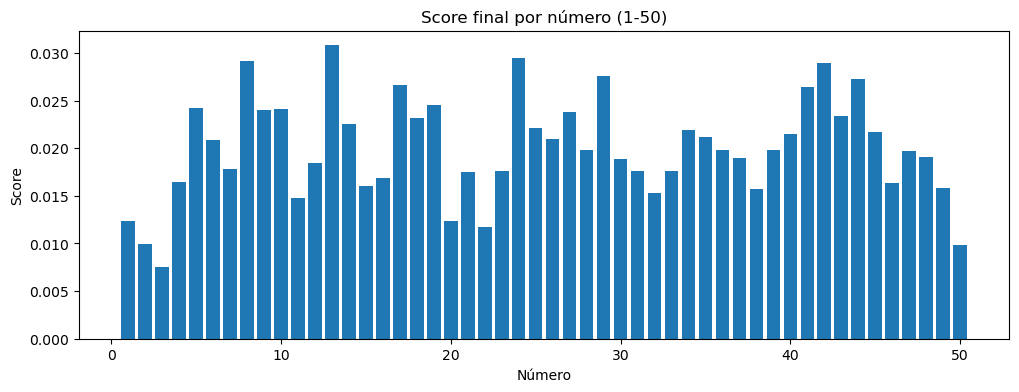

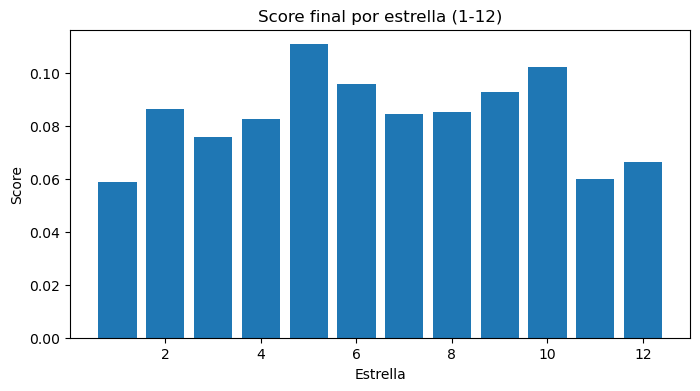

In [10]:
final_nums, final_stars, num_blended_scores, star_blended_scores = make_weighted_combo(
    np.array(best_row['pred_raw_nums']),
    np.array(best_row['pred_raw_stars']),
    float(best_row['alpha_num']),
    float(best_row['alpha_star']),
    df,
    recent_window=recent_window
)

plt.figure(figsize=(12, 4))
plt.bar(range(1, 51), num_blended_scores[1:])
plt.title('Score final por número (1-50)')
plt.xlabel('Número')
plt.ylabel('Score')
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(range(1, 13), star_blended_scores[1:])
plt.title('Score final por estrella (1-12)')
plt.xlabel('Estrella')
plt.ylabel('Score')
plt.show()

## 10. Exportación opcional a CSV

In [11]:
export_ranking = results_df.copy()
export_top5 = top5_combos.copy()
export_raw_vs_final = raw_vs_final.copy()
export_comparison = comparison_final.copy()

# Descomenta estas líneas si quieres guardar los resultados en archivos CSV
# export_ranking.to_csv('euromillones_v4_ranking.csv', index=False)
# export_top5.to_csv('euromillones_v4_top5.csv', index=False)
# export_raw_vs_final.to_csv('euromillones_v4_raw_vs_final.csv', index=False)
# export_comparison.to_csv('euromillones_v4_comparacion.csv', index=False)

print('Listo para exportar si descomentas las líneas CSV.')

Listo para exportar si descomentas las líneas CSV.


## 11. Resumen final

In [12]:
summary_final = pd.DataFrame({
    'elemento': ['mejor_window', 'alpha_num', 'alpha_star', 'predicción cruda redondeada', 'combinación final', 'top 5 disponible'],
    'valor': [
        int(best_row['window_length']),
        float(best_row['alpha_num']),
        float(best_row['alpha_star']),
        f"{best_row['raw_nums_rounded']} + estrellas {best_row['raw_stars_rounded']}",
        f"{best_row['suggested_nums']} + estrellas {best_row['suggested_stars']}",
        'sí'
    ]
})

display(summary_final)
print('Combinación final sugerida:', best_row['suggested_nums'], '| Estrellas:', best_row['suggested_stars'])

,elemento,valor
0,mejor_window,100
1,alpha_num,0.3
2,alpha_star,0.3
3,predicción cruda redondeada,"[9, 18, 26, 34, 43] + estrellas [4, 8]"
4,combinación final,"[8, 13, 24, 29, 42] + estrellas [5, 10]"
5,top 5 disponible,sí


Combinación final sugerida: [8, 13, 24, 29, 42] | Estrellas: [5, 10]
